**Ejercicio desarrollado por Vaibhav Vaibhav**
https://www.delftstack.com/es/howto/python/gradient-descent-python/

# INTRODUCCION

Entrenaremos un modelo de aprendizaje automático para la ecuación y = (0.5x + 2), que tiene la forma y = (mx + c) o y = (ax + b). Esencialmente, entrenará un modelo de aprendizaje automático sobre los datos generados mediante esta ecuación. El modelo adivinará los valores de (m y c) o (a y b), es decir, la pendiente y la intersección, respectivamente. Dado que los modelos de aprendizaje automático necesitan algunos datos de los que aprender y algunos datos de prueba para probar su precisión, generaremos los mismos utilizando un script de Python. Realizaremos regresión lineal para realizar esta tarea.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

Esta función realiza la regresión lineal sobre los datos y devuelve los pesos del modelo,
el sesgo del modelo y los costos o pérdidas intermedios para cada época.


In [ ]:
def linear_regression(inputs, targets, epochs, learning_rate):
    """
    A utility function to run linear regression and get weights and bias
    """
    costs = []  # A list to store losses at each epoch
    values_count = inputs.shape[1]  # Number of values within a single input
    size = inputs.shape[0]  # Total number of inputs
    weights = np.zeros((values_count, 1))  # Weights
    bias = 0  # Bias

    for epoch in range(epochs):
        # Calculating the predicted values
        predicted = np.dot(inputs, weights) + bias
        loss = predicted - targets  # Calculating the individual loss for all the inputs
        d_weights = np.dot(inputs.T, loss) / (2 * size)  # Calculating gradient
        d_bias = np.sum(loss) / (2 * size)  # Calculating gradient
        weights = weights - (learning_rate * d_weights)  # Updating the weights
        bias = bias - (learning_rate * d_bias)  # Updating the bias
        cost = np.sqrt(
            np.sum(loss ** 2) / (2 * size)
        )  # Root Mean Squared Error Loss or RMSE Loss
        costs.append(cost)  # Storing the cost
        print(
            f"Iteration: {epoch + 1} | Cost/Loss: {cost} | Weight: {weights} | Bias: {bias}"
        )

    return weights, bias, costs

Esta función acepta entradas, objetivos, pesos y sesgos y predice la salida de las entradas.
Luego trazará un gráfico para mostrar qué tan cerca estaban las predicciones del modelo de los valores reales.


In [ ]:
def plot_test(inputs, targets, weights, bias):
    """
    A utility function to test the weights
    """
    predicted = np.dot(inputs, weights) + bias
    predicted = predicted.astype(int)
    plt.plot(
        predicted,
        [i for i in range(len(predicted))],
        #color=np.random.random(3),
        color='red',
        label="Predictions",
        linestyle="None",
        marker="x",
    )
    plt.plot(
        targets,
        [i for i in range(len(targets))],
        #color=np.random.random(3),
        color='blue',
        label="Targets",
        linestyle="None",
        marker="o",
    )
    plt.xlabel("Indexes")
    plt.ylabel("Values")
    plt.title("Predictions VS Targets")
    plt.legend()
    plt.show()


Esta función calcula y devuelve el error cuadrático medio de algunas entradas,
pesos, sesgos y objetivos o etiquetas.


In [ ]:
def rmse(inputs, targets, weights, bias):
    """
    A utility function to calculate RMSE or Root Mean Squared Error
    """
    predicted = np.dot(inputs, weights) + bias
    mse = np.sum((predicted - targets) ** 2) / (2 * inputs.shape[0])
    return np.sqrt(mse)


Esta función genera datos de muestra para que el modelo de aprendizaje automático se entrene mediante la ecuación y = ax + b. Genera los datos de entrenamiento y prueba. m y n se refieren al número de muestras de entrenamiento y prueba generadas, respectivamente.

In [ ]:
def generate_data(m, n, a, b):
    """
    A function to generate training data, training labels, testing data, and testing inputs
    """
    x, y, tx, ty = [], [], [], []

    for i in range(1, m + 1):
        x.append([float(i)])
        y.append([float(i) * a + b])

    for i in range(n):
        tx.append([float(random.randint(1000, 100000))])
        ty.append([tx[-1][0] * a + b])

    return np.array(x), np.array(y), np.array(tx), np.array(ty)

Streaming output truncated to the last 5000 lines.
Iteration: 195001 | Cost/Loss: 0.06230978909373692 | Weight: [[0.50088193]] | Bias: 1.8233219825699096
Iteration: 195002 | Cost/Loss: 0.06230901412856748 | Weight: [[0.50088192]] | Bias: 1.823324179966372
Iteration: 195003 | Cost/Loss: 0.062308239173031646 | Weight: [[0.50088191]] | Bias: 1.8233263773355046
Iteration: 195004 | Cost/Loss: 0.06230746422713631 | Weight: [[0.50088189]] | Bias: 1.823328574677308
Iteration: 195005 | Cost/Loss: 0.062306689290880984 | Weight: [[0.50088188]] | Bias: 1.8233307719917824
Iteration: 195006 | Cost/Loss: 0.06230591436426168 | Weight: [[0.50088187]] | Bias: 1.8233329692789282
Iteration: 195007 | Cost/Loss: 0.06230513944728193 | Weight: [[0.50088186]] | Bias: 1.8233351665387456
Iteration: 195008 | Cost/Loss: 0.06230436453993936 | Weight: [[0.50088185]] | Bias: 1.8233373637712351
Iteration: 195009 | Cost/Loss: 0.06230358964223309 | Weight: [[0.50088184]] | Bias: 1.823339560976397
Iteration: 195010 | Cos

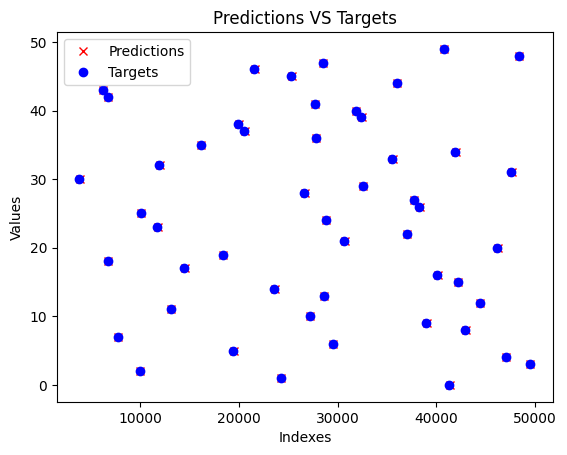

Weights: [0.5008287639956263]
Bias: 1.8339723159878247
RMSE on training data: 0.05855296238504223
RMSE on testing data: 36.02633779980939


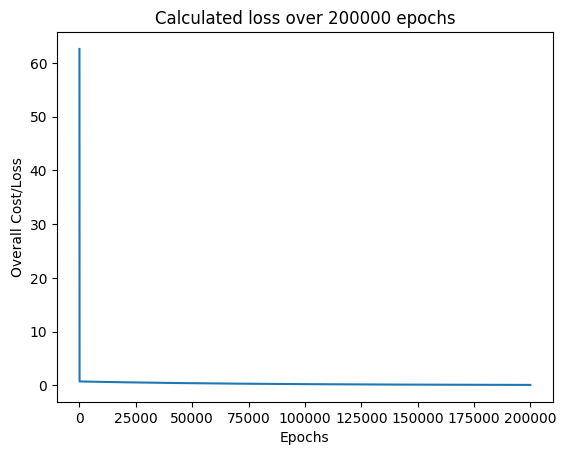

In [ ]:
learning_rate = 0.0001  # Learning rate
epochs = 200000  # Número de épocas
a = 0.5  # y = ax + b
b = 2.0  # y = ax + b
inputs, targets, train_inputs, train_targets = generate_data(300, 50, a, b)
weights, bias, costs = linear_regression(
    inputs, targets, epochs, learning_rate
)  # Regresión Lineal
indexes = [i for i in range(1, epochs + 1)]
plot_test(train_inputs, train_targets, weights, bias)  # Testing
print(f"Weights: {[x[0] for x in weights]}")
print(f"Bias: {bias}")
print(
    f"RMSE on training data: {rmse(inputs, targets, weights, bias)}"
)  # RMSE en datos de entrenamiento
print(
    f"RMSE on testing data: {rmse(train_inputs, train_targets, weights, bias)}"
)  # RMSE en datos de test
plt.plot(indexes, costs)
plt.xlabel("Epochs")
plt.ylabel("Overall Cost/Loss")
plt.title(f"Calculated loss over {epochs} epochs")
plt.show()

# CONCLUSIONES

Una vez que se entrena el modelo, el programa probará el modelo y dibujará una gráfica con las predicciones del modelo y los valores reales.

Como podemos ver, las predicciones casi se superponen a todos los valores verdaderos (las predicciones se representan mediante x y los objetivos se representan mediante o). Esto significa que el modelo ha predicho casi con éxito los valores para a y b o m y c.

A continuación, el programa imprime todas las pérdidas encontradas durante el entrenamiento del modelo.

Como podemos ver, la pérdida cayó inmediatamente desde alrededor de 60 cerca de 0 y continuó manteniéndose en torno a él durante el resto de las épocas.

Por último, se imprimieron las pérdidas de RMSE para los datos de entrenamiento y prueba, y los valores predichos para a y b o los parámetros del modelo.

La ecuación que usamos para este ejemplo fue y = 0.5x + 2, donde a = 0.5 y b = 2. Y, el modelo predijo a = 0.50082 y b = 1.83397, que están muy cerca de los valores reales. Es por eso que nuestras predicciones se superponen con los verdaderos objetivos.

Para este ejemplo, establecemos el número de épocas en 200000 y la tasa de aprendizaje en 0.0001. Afortunadamente, este es solo un conjunto de configuraciones que nos dio resultados extremadamente buenos, casi perfectos.
